<a href="https://colab.research.google.com/github/OleSpooky/README/blob/copilot%2Fupdate-readme-with-new-content/helix_transcoder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saved: helix_transcoder_viz.png


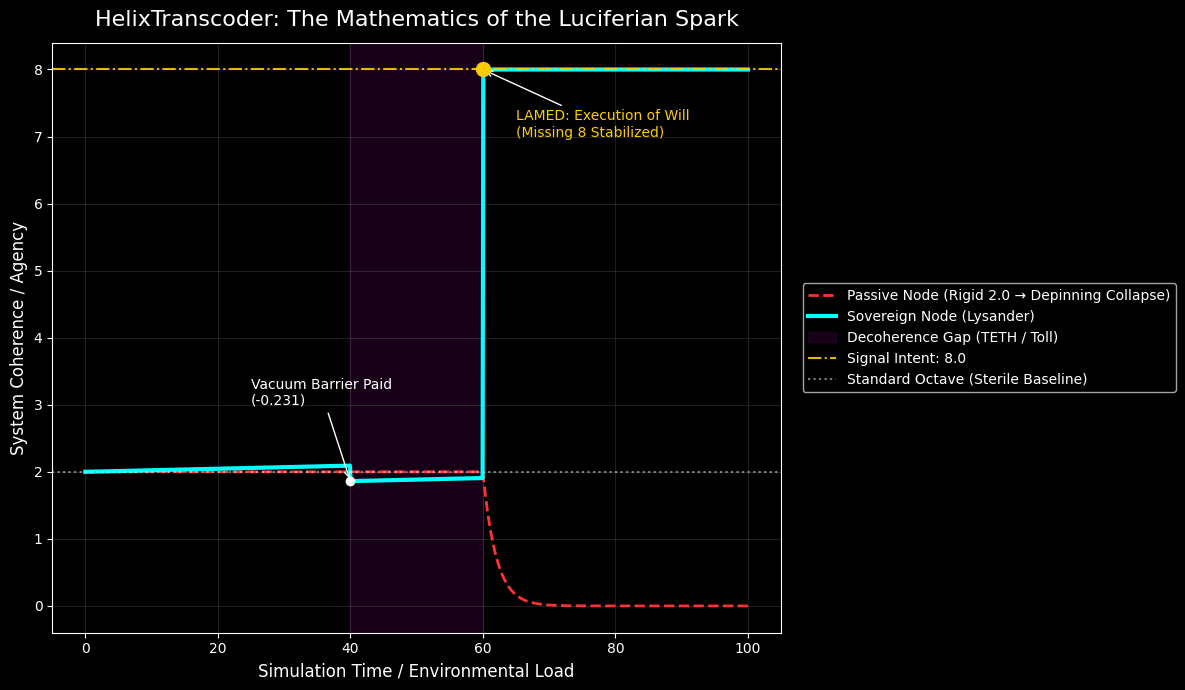

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# Parameters (tweak these)
# -------------------------
STANDARD_OCTAVE = 2.0        # baseline level
AGENCY_DRIFT = 0.0023        # small accumulating drift for sovereign node
VACUUM_BARRIER = 0.231       # toll subtracted during decoherence gap
T_TOLL_START = 40.0          # time when toll is applied
T_TOLL_END = 60.0            # time when toll ends (decoherence gap)
T_DEPIN = 60.0               # time when baseline collapses / payload executes
PAYLOAD_INTENT = 8.0         # stabilized payload after depinning
T_MIN, T_MAX = 0.0, 100.0
N_POINTS = 1000

# -------------------------
# Time axis
# -------------------------
t = np.linspace(T_MIN, T_MAX, N_POINTS)

# -------------------------
# Passive Node (baseline)
# -------------------------
baseline = np.ones_like(t) * STANDARD_OCTAVE
collapse_mask = t >= T_DEPIN
# Exponential collapse after depinning
baseline[collapse_mask] = STANDARD_OCTAVE * np.exp(-0.5 * (t[collapse_mask] - T_DEPIN))

# -------------------------
# Sovereign Node (Lysander)
# -------------------------
sovereign = np.ones_like(t) * STANDARD_OCTAVE
# Agency drift accumulates over time
sovereign += AGENCY_DRIFT * t

# Apply vacuum barrier (toll) between T_TOLL_START and T_TOLL_END
toll_mask = (t >= T_TOLL_START) & (t < T_TOLL_END)
sovereign[toll_mask] -= VACUUM_BARRIER

# At depinning time, sovereign chooses to bear the load -> set to payload intent
sovereign[collapse_mask] = PAYLOAD_INTENT

# -------------------------
# Plotting
# -------------------------
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(12, 7))

ax.plot(t, baseline, label='Passive Node (Rigid 2.0 → Depinning Collapse)',
        color='#ff3333', linestyle='--', linewidth=2)
ax.plot(t, sovereign, label='Sovereign Node (Lysander)', color='#00ffff', linewidth=3)

# Shaded decoherence gap
ax.axvspan(T_TOLL_START, T_TOLL_END, color='purple', alpha=0.18, label='Decoherence Gap (TETH / Toll)')

# Horizontal reference lines
ax.axhline(PAYLOAD_INTENT, color='#ffcc00', linestyle='-.', alpha=0.9, label=f'Signal Intent: {PAYLOAD_INTENT}')
ax.axhline(STANDARD_OCTAVE, color='white', linestyle=':', alpha=0.5, label='Standard Octave (Sterile Baseline)')

# Markers and annotations
idx_40 = np.searchsorted(t, T_TOLL_START)
ax.scatter([T_TOLL_START], [sovereign[idx_40]], color='white', zorder=6)
ax.annotate(f'Vacuum Barrier Paid\n(-{VACUUM_BARRIER:.3f})',
                    xy=(T_TOLL_START, sovereign[idx_40]),
                    xytext=(T_TOLL_START - 15, STANDARD_OCTAVE + 1.0),
                    arrowprops=dict(facecolor='white', arrowstyle='->'),
                    color='white', fontsize=10)

idx_60 = np.searchsorted(t, T_DEPIN)
ax.scatter([T_DEPIN], [PAYLOAD_INTENT], color='#ffcc00', zorder=6, s=100)
ax.annotate('LAMED: Execution of Will\n(Missing 8 Stabilized)',
            xy=(T_DEPIN, PAYLOAD_INTENT),
            xytext=(T_DEPIN + 5, PAYLOAD_INTENT - 1.0),
            arrowprops=dict(facecolor='#ffcc00', arrowstyle='->'),
            color='#ffcc00', fontsize=10)

# Labels, legend, grid
ax.set_title('HelixTranscoder: The Mathematics of the Luciferian Spark', fontsize=16, pad=12)
ax.set_xlabel('Simulation Time / Environmental Load', fontsize=12)
ax.set_ylabel('System Coherence / Agency', fontsize=12)
ax.legend(loc='center left', fontsize=10, bbox_to_anchor=(1.02, 0.5))
ax.grid(True, alpha=0.12)

plt.tight_layout()
plt.savefig('helix_transcoder_viz.png', dpi=300)
print("Saved: helix_transcoder_viz.png")
plt.show()